<a href="https://colab.research.google.com/github/Saranga99/ml-cyber/blob/main/task_2_network_intrusion_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 2: Cyber Attack Detection Using Machine Learning and Deep Learning

## Problem Statement

Network intrusion detection is an important cybersecurity task because computer networks are continuously exposed to malicious activities such as Denial of Service attacks, probing, unauthorized remote access, and privilege escalation attacks.

The objective of this section is to develop a multi-class Network Intrusion Detection System (NIDS) using the NSL-KDD dataset. The system will classify network traffic into five major categories:

- Normal
- DoS (Denial of Service)
- Probe
- R2L (Remote to Local)
- U2R (User to Root)

The NSL-KDD dataset contains numerical and categorical network traffic features such as protocol type, network service, connection flags, packet statistics, login information, and host-based traffic statistics.

The following tasks will be performed:

1. Load and explore the NSL-KDD dataset.
2. Assign the correct feature names to the dataset.
3. Handle missing values.
4. Convert individual attack names into five major attack categories.
5. Encode categorical features.
6. Standardize numerical features.
7. Split the dataset into training and testing sets.
8. Apply Principal Component Analysis (PCA) for dimensionality reduction.
9. Train a Random Forest classifier as the classical machine learning model.
10. Develop a 1D Convolutional Neural Network (CNN) using TensorFlow/Keras.
11. Evaluate both models using:
    - Accuracy
    - Precision
    - Recall
    - F1-score
    - Precision-Recall curves
    - Confusion Matrix
12. Compare the performance of the Random Forest and CNN models.

The final objective is to determine how effectively traditional machine learning and deep learning techniques can identify different categories of cyber attacks from network traffic.

## Step 1: Import Required Libraries

In this step, the Python libraries required for data manipulation, preprocessing, dimensionality reduction, machine learning, deep learning, and model evaluation are imported.

Pandas and NumPy are used for data processing. Scikit-learn is used for preprocessing, PCA, Random Forest, and evaluation. TensorFlow/Keras is used to construct the deep learning CNN model. Matplotlib is used for data and model visualizations.

In [253]:
# ============================================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# PCA
from sklearn.decomposition import PCA

# Machine Learning
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

SEED = 42

# Reproducibility
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


## Step 2: Define NSL-KDD Feature Names

The KDDTrain+.txt file does not contain a header row. Therefore, the correct NSL-KDD feature names must be manually assigned.

The dataset contains 41 network traffic features followed by:

- `outcome`: the attack or normal traffic label
- `level`: the difficulty level assigned to the NSL-KDD observation

This results in a total of 43 columns.

In [254]:
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root',
    'num_file_creations','num_shells','num_access_files','num_outbound_cmds',
    'is_host_login','is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate',
    'diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate',
    'dst_host_srv_rerror_rate','outcome','level'
]

print("Total columns:", len(columns))

Total columns: 43


## Step 3: Load the NSL-KDD Dataset

In [255]:
import kagglehub
path = kagglehub.dataset_download("hassan06/nslkdd")

Using Colab cache for faster access to the 'nslkdd' dataset.


In [256]:
df = pd.read_csv(path+"/KDDTrain+.txt")
# Assign name for columns
df.columns = columns

In [257]:
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome,level
0,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,121,19,0.0,0.0,1.0,1.0,0.16,0.06,0.00,255,19,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


## Step 4: Explore the Dataset

The dataset structure, data types, statistical information, and original attack labels are examined before preprocessing.

This helps verify that the dataset has been loaded correctly and provides an understanding of the available variables.

In [258]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nDataset Information:")
df.info()

Rows: 125972
Columns: 43

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125972 entries, 0 to 125971
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125972 non-null  int64  
 1   protocol_type                125972 non-null  object 
 2   service                      125972 non-null  object 
 3   flag                         125972 non-null  object 
 4   src_bytes                    125972 non-null  int64  
 5   dst_bytes                    125972 non-null  int64  
 6   land                         125972 non-null  int64  
 7   wrong_fragment               125972 non-null  int64  
 8   urgent                       125972 non-null  int64  
 9   hot                          125972 non-null  int64  
 10  num_failed_logins            125972 non-null  int64  
 11  logged_in                    125972 non-null  int64  
 12  num_comprom

In [259]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,125972.0,287.146929,2.604526e+03,0.0,0.00,0.00,0.00,4.290800e+04
src_bytes,125972.0,45567.100824,5.870354e+06,0.0,0.00,44.00,276.00,1.379964e+09
dst_bytes,125972.0,19779.271433,4.021285e+06,0.0,0.00,0.00,516.00,1.309937e+09
land,125972.0,0.000198,1.408613e-02,0.0,0.00,0.00,0.00,1.000000e+00
wrong_fragment,125972.0,0.022688,2.535310e-01,0.0,0.00,0.00,0.00,3.000000e+00
urgent,125972.0,0.000111,1.436608e-02,0.0,0.00,0.00,0.00,3.000000e+00
hot,125972.0,0.204411,2.149977e+00,0.0,0.00,0.00,0.00,7.700000e+01
num_failed_logins,125972.0,0.001222,4.523932e-02,0.0,0.00,0.00,0.00,5.000000e+00
logged_in,125972.0,0.395739,4.890107e-01,0.0,0.00,0.00,1.00,1.000000e+00
num_compromised,125972.0,0.279253,2.394214e+01,0.0,0.00,0.00,0.00,7.479000e+03


## Step 5: Convert Individual Attack Types into Five Main Classes

NSL-KDD contains several individual cyber attack names. For multi-class intrusion detection, these individual attacks are grouped into five standard categories.

### Normal
Legitimate network traffic.

### DoS - Denial of Service
Attacks designed to make a computer or network service unavailable by overwhelming its resources.

Examples include:
- neptune
- smurf
- back
- teardrop
- pod
- land

### Probe
Attacks in which an attacker scans a network to collect information about systems, services, or vulnerabilities.

Examples include:
- satan
- ipsweep
- portsweep
- nmap

### R2L - Remote to Local
An attacker remotely attempts to gain unauthorized access to a local account.

Examples include:
- guess_passwd
- ftp_write
- warezclient
- warezmaster
- imap

### U2R - User to Root
An attacker with normal user-level access attempts to obtain administrator or root privileges.

Examples include:
- buffer_overflow
- rootkit
- loadmodule
- perl

The conversion simplifies the many attack names into meaningful cybersecurity categories suitable for multi-class classification.

In [260]:
print("Number of original labels:", df["outcome"].nunique())
print("\nOriginal attack distribution:")
print(df["outcome"].value_counts())

Number of original labels: 23

Original attack distribution:
outcome
normal             67342
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


In [261]:
attack_mapping = {
    "normal":"Normal",

    "back":"DoS",
    "land":"DoS",
    "neptune":"DoS",
    "pod":"DoS",
    "smurf":"DoS",
    "teardrop":"DoS",
    "apache2":"DoS",
    "mailbomb":"DoS",
    "processtable":"DoS",
    "udpstorm":"DoS",

    "ipsweep":"Probe",
    "nmap":"Probe",
    "portsweep":"Probe",
    "satan":"Probe",
    "mscan":"Probe",
    "saint":"Probe",

    "ftp_write":"R2L",
    "guess_passwd":"R2L",
    "imap":"R2L",
    "multihop":"R2L",
    "phf":"R2L",
    "spy":"R2L",
    "warezclient":"R2L",
    "warezmaster":"R2L",
    "sendmail":"R2L",
    "named":"R2L",
    "snmpgetattack":"R2L",
    "snmpguess":"R2L",
    "xlock":"R2L",
    "xsnoop":"R2L",
    "worm":"R2L",

    "buffer_overflow":"U2R",
    "loadmodule":"U2R",
    "perl":"U2R",
    "rootkit":"U2R",
    "httptunnel":"U2R",
    "ps":"U2R",
    "sqlattack":"U2R",
    "xterm":"U2R"
}

df["outcome"] = df["outcome"].map(attack_mapping)

print("Unmapped attacks:", df.loc[df["outcome"].isna(), "outcome"].unique())
print("\nFinal class distribution:")
print(df["outcome"].value_counts())

Unmapped attacks: []

Final class distribution:
outcome
Normal    67342
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


In [262]:
# used two classes wheather it's an attack or not
# df.loc[df['outcome'] == "normal", "outcome"] = 'normal'
# df.loc[df['outcome'] != 'normal', "outcome"] = 'attack'

## Step 6: Examine Class Distribution

---



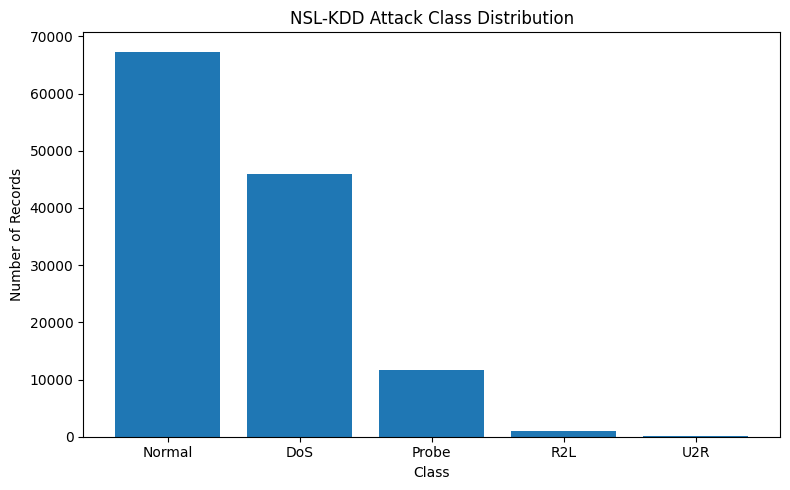

In [263]:
class_counts = df["outcome"].value_counts()

plt.figure(figsize=(8,5))
plt.bar(class_counts.index, class_counts.values)
plt.title("NSL-KDD Attack Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

## Step 7: Handle Missing Values

Missing or infinite values can cause problems during model training.

Infinite values are first converted into missing values. Numerical missing values will later be replaced using the median, while categorical missing values will be replaced using the most frequent value.

In [264]:
print("Missing values before processing:", df.isnull().sum().sum())

df.replace([np.inf, -np.inf], np.nan, inplace=True)

print("Missing values after converting infinity:", df.isnull().sum().sum())

Missing values before processing: 0
Missing values after converting infinity: 0


## Step 8: Separate Input Features and Target Variable

The network traffic features are separated from the target variable.

`outcome` is removed because it contains the original attack name.

`outcome` is the target variable that the models will predict.

`level` is also removed because it represents the NSL-KDD difficulty score rather than an actual network traffic feature.

In [265]:
X = df.drop(columns=["outcome", "level"])
y = df["outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", y.unique())

X shape: (125972, 41)
y shape: (125972,)
Classes: ['Normal' 'DoS' 'R2L' 'Probe' 'U2R']


## Step 9: Identify Numerical and Categorical Features

The NSL-KDD dataset contains few categorical fearures

These variables require categorical encoding. All remaining input features are numerical and will be standardized.

In [266]:
categorical_features = ['is_host_login','protocol_type','service','flag','land', 'logged_in','is_guest_login']

In [267]:
numerical_features = [col for col in X.columns if col not in categorical_features]

print("Numerical features:", len(numerical_features))
print("Categorical features:", categorical_features)

Numerical features: 34
Categorical features: ['is_host_login', 'protocol_type', 'service', 'flag', 'land', 'logged_in', 'is_guest_login']


In [268]:
df.shape

(125972, 43)

## Step 10: Split the Dataset

The dataset is divided into 80% training data and 20% testing data.

Stratified sampling is used to maintain approximately the same proportion of each attack class in both datasets.

The split is performed before preprocessing to prevent information from the testing dataset leaking into model training.

In [269]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED, shuffle=True, stratify=y)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("\nTraining classes:")
print(y_train.value_counts())

Training shape: (100777, 41)
Testing shape: (25195, 41)

Training classes:
outcome
Normal    53873
DoS       36741
Probe      9325
R2L         796
U2R          42
Name: count, dtype: int64


## Step 11: Preprocess Numerical and Categorical Features

Numerical features are processed by replacing missing values with the median and then standardizing them using StandardScaler.

Categorical features are processed by replacing missing values with the most frequent category and then applying One-Hot Encoding.

The preprocessing pipeline is fitted only on the training dataset to prevent data leakage.

In [270]:
numeric_transformer = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])

try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)


categorical_transformer = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", encoder)])

preprocessor = ColumnTransformer([("numerical", numeric_transformer, numerical_features), ("categorical", categorical_transformer, categorical_features)])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training shape after preprocessing:", X_train_processed.shape)
print("Testing shape after preprocessing:", X_test_processed.shape)

Training shape after preprocessing: (100777, 126)
Testing shape after preprocessing: (25195, 126)


## Step 12: Encode Target Labels

Machine learning and deep learning models work with numerical target values.

LabelEncoder converts the five two categories into integer values. The same encoding is used for both Random Forest and the TensorFlow CNN.

In [271]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

class_names = label_encoder.classes_
num_classes = len(class_names)

for i, name in enumerate(class_names):
    print(f"{i} = {name}")

0 = DoS
1 = Normal
2 = Probe
3 = R2L
4 = U2R


## Step 13: Apply Principal Component Analysis

One-Hot Encoding increases the number of input features. PCA is used to reduce dimensionality while retaining most of the information contained in the dataset.

The PCA model is configured to retain 95% of the total variance.

PCA is fitted only on the training data and the same transformation is then applied to the testing data.

In [272]:
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_processed)
X_test_pca = pca.transform(X_test_processed)

print("Features before PCA:", X_train_processed.shape[1])
print("Features after PCA:", X_train_pca.shape[1])
print("Explained variance:", round(pca.explained_variance_ratio_.sum(), 4))

Features before PCA: 126
Features after PCA: 22
Explained variance: 0.9508


## Step 14: Visualize PCA Explained Variance

The cumulative explained variance graph shows how much information is retained as additional principal components are included.

The selected PCA components preserve approximately 95% of the total variance.

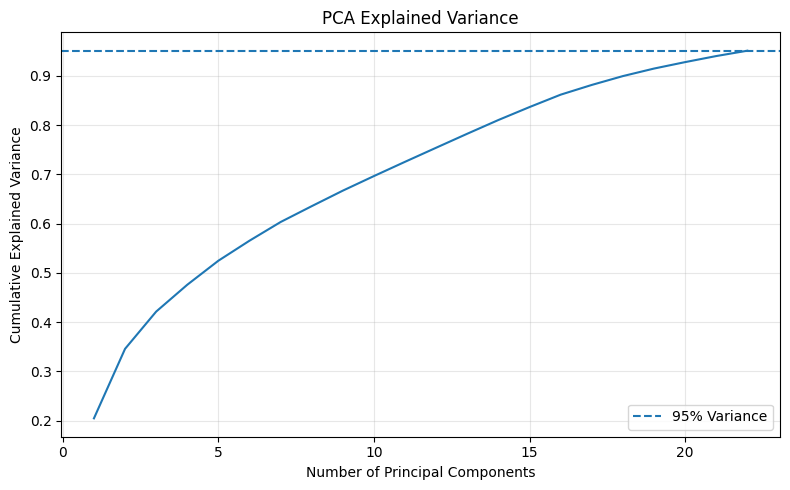

In [273]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance)
plt.axhline(0.95, linestyle="--", label="95% Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 15: Train the Random Forest Model

Random Forest is used as the classical machine learning approach.

It combines multiple Decision Trees and produces the final prediction using the combined output of those trees.

Class balancing is enabled because some cyber attack classes contain significantly fewer observations than others.

In [274]:
rf_model = RandomForestClassifier(
    max_depth=10,
    n_estimators=50,
    random_state=SEED,
    class_weight="balanced_subsample",
    n_jobs=-1
)

rf_model.fit(X_train_pca, y_train_encoded)

print("Random Forest training completed.")

Random Forest training completed.


## Step 16: Evaluate Random Forest

The Random Forest model is evaluated using Accuracy, Macro Precision, Macro Recall, Macro F1-score, and a detailed classification report.

Macro averaging gives equal importance to each attack category and is useful because the dataset is imbalanced.

In [275]:
rf_pred = rf_model.predict(X_test_pca)
rf_prob = rf_model.predict_proba(X_test_pca)

rf_accuracy = accuracy_score(y_test_encoded, rf_pred)
rf_precision = precision_score(y_test_encoded, rf_pred, average="macro", zero_division=0)
rf_recall = recall_score(y_test_encoded, rf_pred, average="macro", zero_division=0)
rf_f1 = f1_score(y_test_encoded, rf_pred, average="macro", zero_division=0)

print("Random Forest Accuracy:", round(rf_accuracy, 4))
print("Random Forest Precision:", round(rf_precision, 4))
print("Random Forest Recall:", round(rf_recall, 4))
print("Random Forest F1-score:", round(rf_f1, 4))

print("\nClassification Report:\n")
print(classification_report(
    y_test_encoded,
    rf_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
))

Random Forest Accuracy: 0.9904
Random Forest Precision: 0.858
Random Forest Recall: 0.8621
Random Forest F1-score: 0.8551

Classification Report:

              precision    recall  f1-score   support

         DoS     0.9991    0.9977    0.9984      9186
      Normal     0.9941    0.9884    0.9913     13469
       Probe     0.9609    0.9798    0.9703      2331
         R2L     0.7642    0.9447    0.8449       199
         U2R     0.5714    0.4000    0.4706        10

    accuracy                         0.9904     25195
   macro avg     0.8580    0.8621    0.8551     25195
weighted avg     0.9909    0.9904    0.9906     25195



## Step 17: Random Forest Confusion Matrix

The confusion matrix compares actual attack classes with the classes predicted by Random Forest.

Correct predictions appear along the main diagonal. Values outside the diagonal represent classification errors.

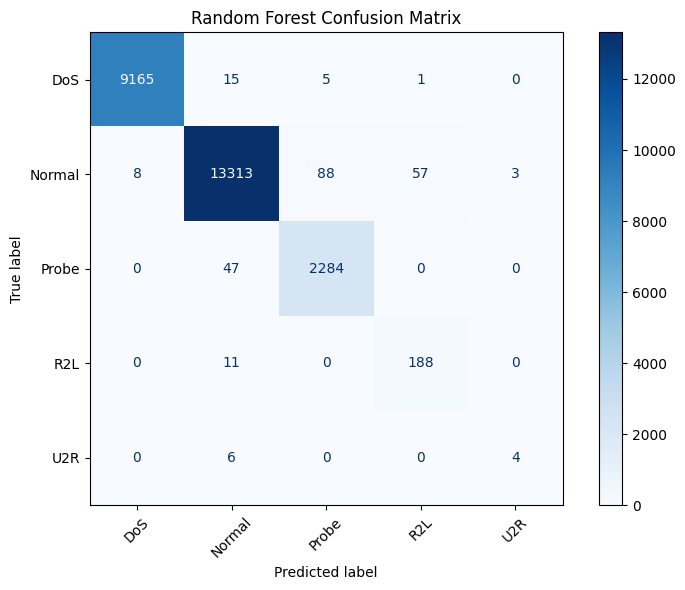

In [276]:
rf_cm = confusion_matrix(y_test_encoded, rf_pred)

fig, ax = plt.subplots(figsize=(8,6))
ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=class_names
).plot(ax=ax, cmap="Blues", values_format="d")

plt.title("Random Forest Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 18: Prepare Data for the CNN

A 1D CNN expects data in three dimensions: samples, sequence length, and channels.

The PCA features are therefore reshaped by adding one channel dimension.

Class weights are also calculated so that rare attack categories receive more importance during neural network training.

In [277]:
X_train_cnn = X_train_pca.reshape(X_train_pca.shape[0], X_train_pca.shape[1], 1)
X_test_cnn = X_test_pca.reshape(X_test_pca.shape[0], X_test_pca.shape[1], 1)

classes = np.unique(y_train_encoded)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_encoded
)
class_weights = dict(zip(classes, weights))

print("CNN training shape:", X_train_cnn.shape)
print("CNN testing shape:", X_test_cnn.shape)
print("Class weights:", class_weights)

CNN training shape: (100777, 22, 1)
CNN testing shape: (25195, 22, 1)
Class weights: {np.int64(0): np.float64(0.5485806047739582), np.int64(1): np.float64(0.3741280418762645), np.int64(2): np.float64(2.161436997319035), np.int64(3): np.float64(25.320854271356783), np.int64(4): np.float64(479.8904761904762)}


## Step 19: Build the TensorFlow CNN

A 1D Convolutional Neural Network is created using TensorFlow and Keras.

Conv1D layers learn patterns from the transformed network features. Batch Normalization helps stabilize training, pooling reduces intermediate dimensions, and Dropout reduces overfitting.

The final Softmax layer contains one output neuron for each of the fve traffic classes.

In [278]:
cnn_model = Sequential([
    Input(shape=(X_train_cnn.shape[1], 1)),
    Conv1D(64, kernel_size=3, activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.30),
    Conv1D(128, kernel_size=3, activation="relu", padding="same"),
    BatchNormalization(),
    GlobalMaxPooling1D(),
    Dense(128, activation="relu"),
    Dropout(0.40),
    Dense(num_classes, activation="softmax")
])

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_14 (Conv1D)              │ (None, 22, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 22, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_15 (Conv1D)              │ (None, 11, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 11, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_7          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,885 (167.52 KB)

 Trainable params: 42,501 (166.02 KB)

 Non-trainable params: 384 (1.50 KB)

## Step 20: Train the CNN

The CNN is trained using the PCA-transformed training data.

Early Stopping stops training when validation loss stops improving and restores the best model weights.

ReduceLROnPlateau decreases the learning rate if validation performance stops improving.

In [279]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history = cnn_model.fit(
    X_train_cnn,
    y_train_encoded,
    validation_split=0.20,
    epochs=50,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.6562 - loss: 2.4673 - val_accuracy: 0.8559 - val_loss: 0.6166 - learning_rate: 0.0010
Epoch 2/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.7168 - loss: 2.8816 - val_accuracy: 0.8404 - val_loss: 0.8183 - learning_rate: 0.0010
Epoch 3/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.7608 - loss: 1.9722 - val_accuracy: 0.8563 - val_loss: 0.5409 - learning_rate: 0.0010
Epoch 4/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.7956 - loss: 1.1594 - val_accuracy: 0.8563 - val_loss: 0.5794 - learning_rate: 0.0010
Epoch 5/50
314/315 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8186 - loss: 0.8791
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
315/315 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.8303 - loss: 1.0461 - val_accuracy: 0.8550 - val_loss: 0.5707 - learning_rate: 0.0010
Epoch 6/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.8237 - los

## Step 21: Plot CNN Training Accuracy

Training and validation accuracy are plotted across epochs.

This helps determine whether the CNN is learning effectively and whether overfitting is occurring.

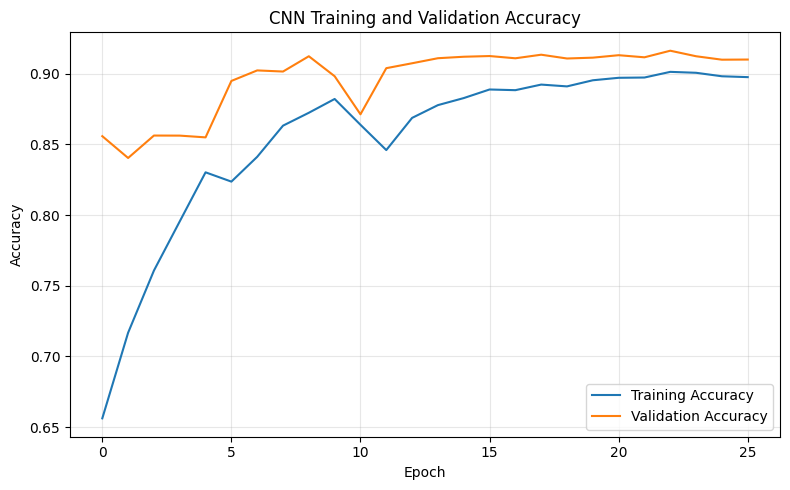

In [280]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 22: Plot CNN Training Loss

Training and validation loss are visualized to examine the CNN learning process.

A decreasing validation loss generally indicates improved generalization to unseen data.

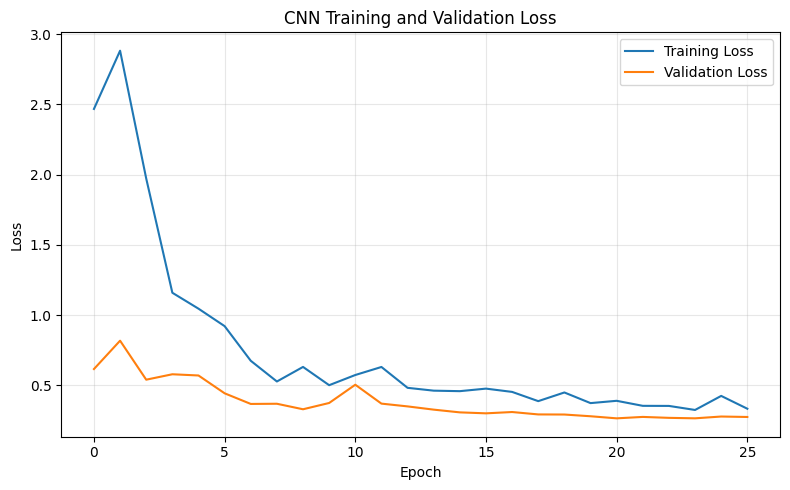

In [281]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 23: Evaluate the CNN

The trained CNN is evaluated using the unseen testing dataset.

The model produces a probability for every attack class. The class with the highest probability is selected as the final prediction.

Accuracy, Precision, Recall, F1-score, and the classification report are then calculated.

In [282]:
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(
    X_test_cnn,
    y_test_encoded,
    verbose=0
)

cnn_prob = cnn_model.predict(X_test_cnn, verbose=0)
cnn_pred = np.argmax(cnn_prob, axis=1)

cnn_accuracy = accuracy_score(y_test_encoded, cnn_pred)
cnn_precision = precision_score(y_test_encoded, cnn_pred, average="macro", zero_division=0)
cnn_recall = recall_score(y_test_encoded, cnn_pred, average="macro", zero_division=0)
cnn_f1 = f1_score(y_test_encoded, cnn_pred, average="macro", zero_division=0)

print("CNN Test Loss:", round(cnn_test_loss, 4))
print("CNN Accuracy:", round(cnn_accuracy, 4))
print("CNN Precision:", round(cnn_precision, 4))
print("CNN Recall:", round(cnn_recall, 4))
print("CNN F1-score:", round(cnn_f1, 4))

print("\nClassification Report:\n")
print(classification_report(
    y_test_encoded,
    cnn_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
))

CNN Test Loss: 0.263
CNN Accuracy: 0.9145
CNN Precision: 0.5893
CNN Recall: 0.8906
CNN F1-score: 0.6192

Classification Report:

              precision    recall  f1-score   support

         DoS     0.9900    0.9659    0.9778      9186
      Normal     0.9751    0.8762    0.9230     13469
       Probe     0.7747    0.9365    0.8479      2331
         R2L     0.1849    0.8744    0.3053       199
         U2R     0.0216    0.8000    0.0421        10

    accuracy                         0.9145     25195
   macro avg     0.5893    0.8906    0.6192     25195
weighted avg     0.9554    0.9145    0.9308     25195



## Step 24: CNN Confusion Matrix

The CNN confusion matrix displays the relationship between actual and predicted attack categories.

It helps identify which types of attacks are classified correctly and which categories are commonly confused.

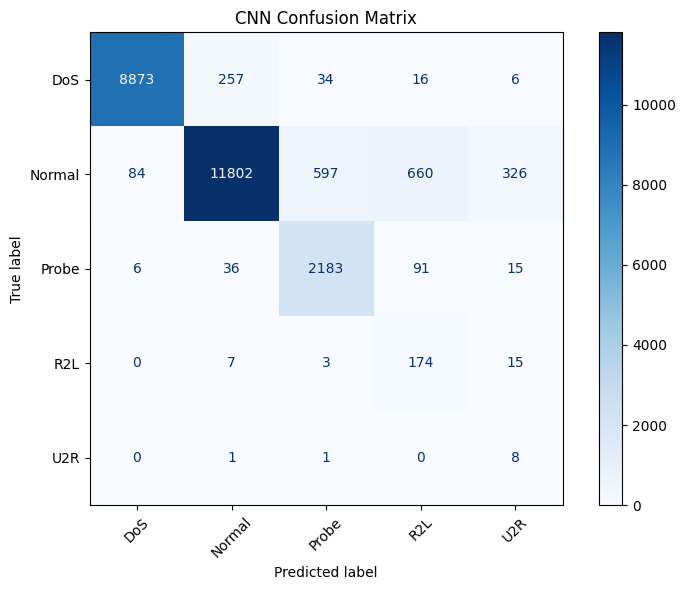

In [283]:
cnn_cm = confusion_matrix(y_test_encoded, cnn_pred)

fig, ax = plt.subplots(figsize=(8,6))
ConfusionMatrixDisplay(
    confusion_matrix=cnn_cm,
    display_labels=class_names
).plot(ax=ax, cmap="Blues", values_format="d")

plt.title("CNN Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 25: CNN ROC Curves

For multi-class classification, a separate ROC curve is calculated for each network traffic class using the One-vs-Rest approach.

For each class, the selected class is treated as the positive class while all remaining classes are treated as negative.

The Area Under the Curve (AUC) measures how effectively the CNN distinguishes each class from the other traffic categories.

An AUC value closer to 1 indicates stronger classification performance.

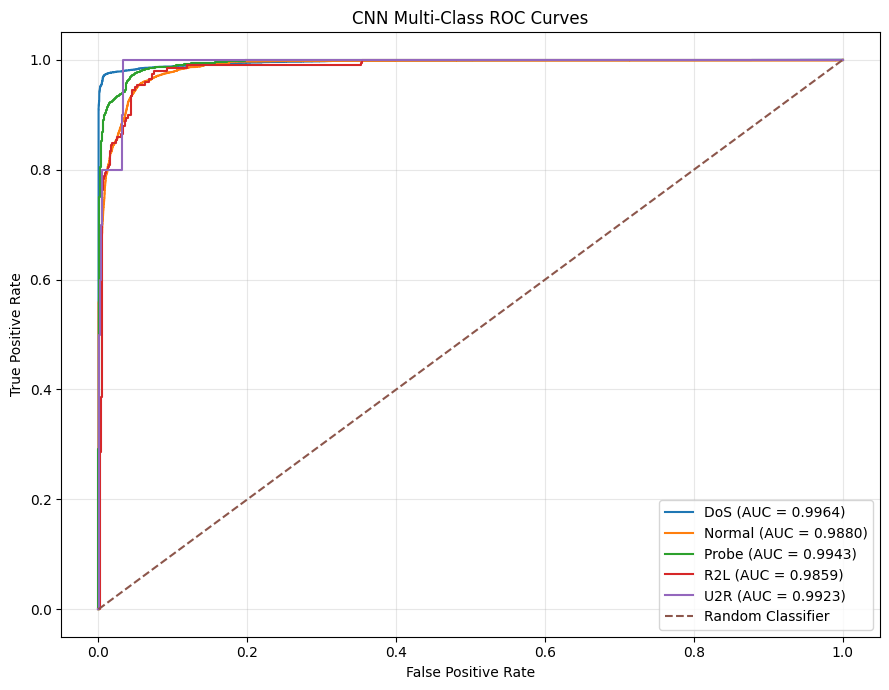

In [284]:
y_test_binary = label_binarize(
    y_test_encoded,
    classes=np.arange(num_classes)
)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(
        y_test_binary[:, i],
        cnn_prob[:, i]
    )
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(9,7))

for i, class_name in enumerate(class_names):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{class_name} (AUC = {roc_auc[i]:.4f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CNN Multi-Class ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 26: CNN Micro-Average ROC Curve

The micro-average ROC curve combines the predictions from all five classes into a single overall ROC curve.

This provides an overall measure of the CNN's ability to distinguish between the different network traffic categories.

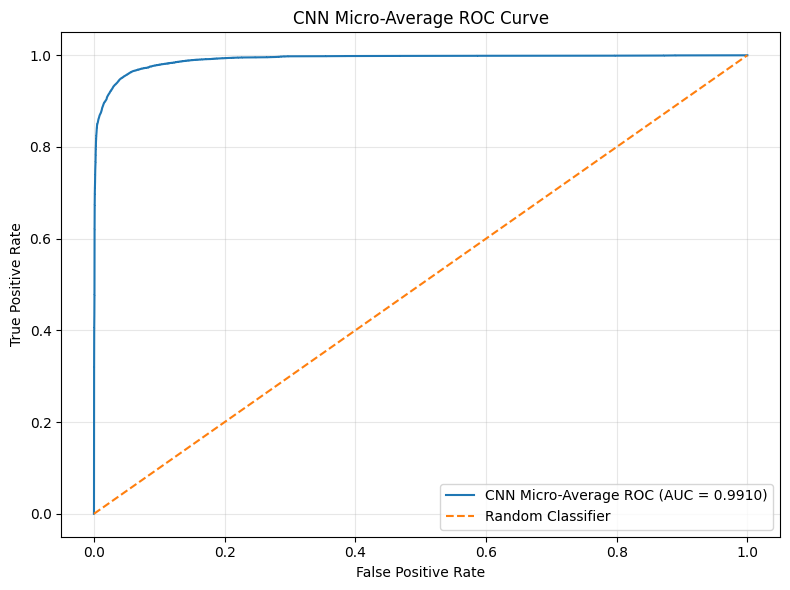

CNN Micro-Average AUC: 0.991


In [285]:
fpr_micro, tpr_micro, _ = roc_curve(
    y_test_binary.ravel(),
    cnn_prob.ravel()
)

cnn_micro_auc = auc(
    fpr_micro,
    tpr_micro
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_micro,
    tpr_micro,
    label=f"CNN Micro-Average ROC (AUC = {cnn_micro_auc:.4f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CNN Micro-Average ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("CNN Micro-Average AUC:", round(cnn_micro_auc, 4))

## Step 27: Calculate Random Forest Performance Metrics

Random Forest is evaluated using Accuracy, Macro Precision, Macro Recall, and Macro F1-score.

Macro averaging calculates each metric independently for every class and then takes the average.

This is useful for NSL-KDD because all five attack categories receive equal importance, including the less frequent R2L and U2R classes.

In [286]:
rf_accuracy = accuracy_score(
    y_test_encoded,
    rf_pred
)

rf_precision = precision_score(
    y_test_encoded,
    rf_pred,
    average="macro",
    zero_division=0
)

rf_recall = recall_score(
    y_test_encoded,
    rf_pred,
    average="macro",
    zero_division=0
)

rf_f1 = f1_score(
    y_test_encoded,
    rf_pred,
    average="macro",
    zero_division=0
)

print("Random Forest Accuracy:", round(rf_accuracy, 4))
print("Random Forest Macro Precision:", round(rf_precision, 4))
print("Random Forest Macro Recall:", round(rf_recall, 4))
print("Random Forest Macro F1-score:", round(rf_f1, 4))

Random Forest Accuracy: 0.9904
Random Forest Macro Precision: 0.858
Random Forest Macro Recall: 0.8621
Random Forest Macro F1-score: 0.8551


## Step 28: Calculate CNN Performance Metrics

The CNN is evaluated using the same metrics as Random Forest.

Using identical evaluation measures allows a fair comparison between the classical machine learning model and the deep learning model.

In [287]:
cnn_accuracy = accuracy_score(
    y_test_encoded,
    cnn_pred
)

cnn_precision = precision_score(
    y_test_encoded,
    cnn_pred,
    average="macro",
    zero_division=0
)

cnn_recall = recall_score(
    y_test_encoded,
    cnn_pred,
    average="macro",
    zero_division=0
)

cnn_f1 = f1_score(
    y_test_encoded,
    cnn_pred,
    average="macro",
    zero_division=0
)

print("CNN Accuracy:", round(cnn_accuracy, 4))
print("CNN Macro Precision:", round(cnn_precision, 4))
print("CNN Macro Recall:", round(cnn_recall, 4))
print("CNN Macro F1-score:", round(cnn_f1, 4))

CNN Accuracy: 0.9145
CNN Macro Precision: 0.5893
CNN Macro Recall: 0.8906
CNN Macro F1-score: 0.6192


## Step 29: Random Forest and CNN Performance Comparison

The following table provides a direct comparison between the classical Random Forest model and the TensorFlow CNN model.

The models are compared using Accuracy, Precision, Recall, and F1-score for binary cyber attack detection.

In [288]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "CNN"],
    "Accuracy": [rf_accuracy, cnn_accuracy],
    "Precision": [rf_precision, cnn_precision],
    "Recall": [rf_recall, cnn_recall],
    "F1-score": [rf_f1, cnn_f1]
})

comparison = comparison.round(4)
comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.9904,0.8580,0.8621,0.8551
1,CNN,0.9145,0.5893,0.8906,0.6192


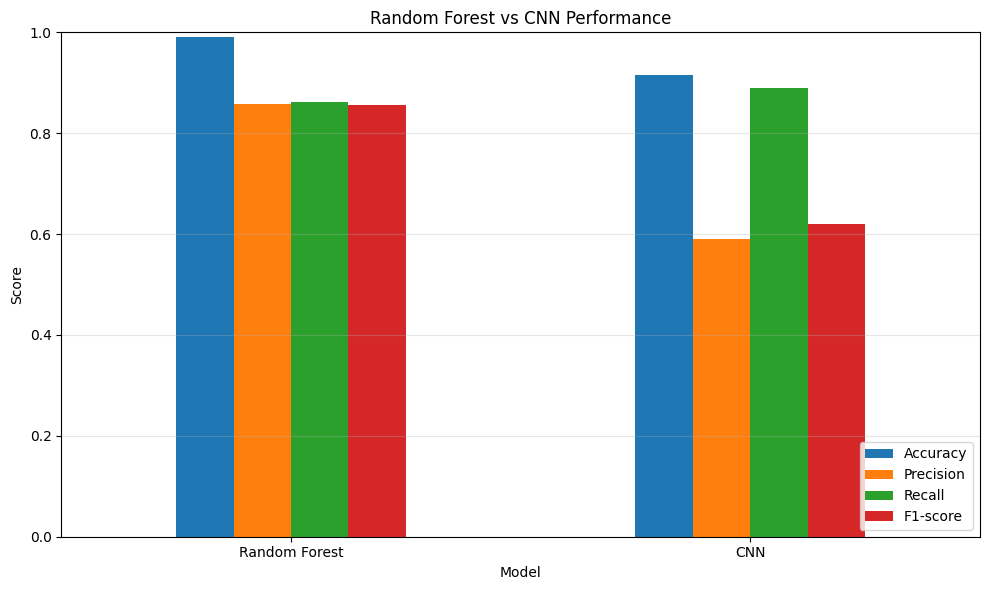

In [289]:
comparison_plot = comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Random Forest vs CNN Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()